<a href="https://colab.research.google.com/github/pritika-v/Mistral-large_from-scratch/blob/main/MISTRAL_LARGE_FROM_SCRATCH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
# torch     -> the deep learning framework we use for all tensor operations
# tiktoken  -> OpenAI's fast tokenizer (same BPE approach  as SentencePiece). Original mistral large uses the SentencePiece Tokenizers
# datasets  -> HuggingFace library to easily download training text data
"""
The original Mistral models use SentencePiece tokenizers, specifically a Byte-Pair Encoding (BPE) tokenizer trained on Mistral's corpus
"""
!pip install torch tiktoken datasets

In [28]:
import torch                          # Main deep learning library
import torch.nn as nn                 # Neural network building blocks (Linear, Module, etc.)
import torch.nn.functional as F       # Functions like softmax, relu, etc.
import tiktoken                       # BPE Tokenizer
import math                           # For sqrt in attention formula
import numpy as np                    # For array operations
from dataclasses import dataclass     # Clean way to define config as a class
from typing import Optional           # For type hints

print("All imports successful!")
print(f"PyTorch version: {torch.__version__}")

# Check if GPU is available — training is faster on GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(torch.cuda.is_available()) #True
print(torch.cuda.get_device_name(0))#Tesla T4
print(f"Using device: {device}")

All imports successful!
PyTorch version: 2.11.0+cu128
True
Tesla T4
Using device: cuda


In [29]:
@dataclass # dataclass auto-generates __init__ construct so we don't have to write it
class MistralConfig: #simply a class whose job is to store model settings like no of layers, kv heads etc
    """
    All hyperparameters for our mini Mistral model.
    The real Mistral Large has:
        - vocab_size     = 32000
        - hidden_size    = 4096
        - num_layers     = 32
        - num_heads      = 32
        - num_kv_heads   = 8   (GQA: 4 query heads share 1 KV head)
        - window_size    = 4096
    We use a tiny version here so it trains in minutes.
    """

    vocab_size: int    = 50257    # Number of tokens the tokenizer knows (tiktoken GPT-2 vocab)
    hidden_size: int   = 256      # Size of every token's vector (real Mistral uses 4096)
    num_layers: int    = 4        # Number of stacked transformer blocks (real Mistral uses 32)
    num_heads: int     = 8        # Number of Query attention heads
    num_kv_heads: int  = 2        # Number of Key/Value heads (GQA: 4 Q heads share 1 KV head)
    head_dim: int      = 32       # Size of each attention head vector (hidden_size / num_heads)
    ffn_hidden: int    = 512      # Hidden size inside the Feed Forward Network
    max_seq_len: int   = 512      # Maximum number of tokens the model can see at once
    window_size: int   = 64       # Sliding Window Attention: each token only looks back 64 tokens
    dropout: float     = 0.1      # Dropout rate: randomly zero out 10% of activations during training
    rope_theta: float  = 10000.0  # Base frequency for RoPE (controls how fast rotations change)

# Create the config object — we'll pass this to every model component
config = MistralConfig()
print("Config created!")
print(f"  Vocabulary size : {config.vocab_size}")
print(f"  Hidden size     : {config.hidden_size}")
print(f"  Layers          : {config.num_layers}")
print(f"  Attention heads : {config.num_heads} Q heads, {config.num_kv_heads} KV heads (GQA)")
print(f"  Window size     : {config.window_size} tokens (Sliding Window Attention)")

Config created!
  Vocabulary size : 50257
  Hidden size     : 256
  Layers          : 4
  Attention heads : 8 Q heads, 2 KV heads (GQA)
  Window size     : 64 tokens (Sliding Window Attention)


TOKENIZER TO CONVERT WoRDS TO NUMBERS/ TOKEN IDS (not embeddings). BPE TOKENIZER IS USED

In [30]:
tokenizer=tiktoken.get_encoding("gpt2") #loading the gpt2 tokenizer from tiktoken. It also used BPE method
sample_text=" I love pizza because it tastes good"
token_ids=tokenizer.encode(sample_text) # encode() converts text-> list of integer token IDs
print(f"Text : {sample_text}")
print(f"Tokens: {token_ids}")


Text :  I love pizza because it tastes good
Tokens: [314, 1842, 14256, 780, 340, 18221, 922]


In [31]:
#decode() converts text-->list of integer token IDs
decoded=tokenizer.decode(token_ids)
print(f"Decoded: {decoded}")


Decoded:  I love pizza because it tastes good


RMSNorm -NORMALIZING HIDDEN STATES

In [32]:
class RMSNorm(nn.Module):#Every neural network component in PyTorch inherits from nn.Module
    """
    This(nn.Module) tells PyTorch: "This class is a neural network layer."

    PyTorch then automatically tracks:

    weights
    gradients
    parameters

    for training.
    """
    """
    Root Mean Square Normalization.
    Keeps values in a stable range so gradients don't explode during training.
    Used in Mistral instead of regular LayerNorm because it's faster.

    Formula: x / sqrt(mean(x^2) + epsilon)  * weight
    """
    #hidden size = no of features in the input vector I-->[0.2, 0.1, 0.8] here hidden size is 3
    def __init__(self,hidden_size:int, eps:float=1e-6):
      super().__init__()
      self.eps=eps #stores 0.000001 . If mean_squared=0 then 1/sqrt(0) will give error so we add a small value of eps                                  # Small number to avoid dividing by zero
      self.weight=nn.Parameter(torch.ones(hidden_size)) # Learnable scale parameter
        #hidden size here is 256. torch.ones(256) gives [1,1,1,...] of size 256. nn.Parameter tells PyTorch "This tensor is trainable" (These weights will be updated during training)


    def forward(self, x:torch.Tensor)->torch.Tensor:
      # x shape: (batch_size, seq_len, hidden_size)-(2,10,256)
        #2 sequences, 10 tokens each, 256 features per token
      x_squared=x.pow(2)
      mean_squared=x_squared.mean(dim=-1, keepdim=True)# keepdim=True means we keep the same number of dimensions (so we can divide x by it later without shape issues)
        #mean(dim=-1) means we take the mean across hidden_size, so we get a single number for each token that represents the average of the squared values across all features.
      x_normed=x*torch.rsqrt(mean_squared+self.eps) # rsqrt = 1/sqrt
      return self.weight*x_normed #the real weight*normalized value. This allows the model to learn how much to scale the normalized output (if weight is 1, it keeps the same scale; if weight is 0.5, it halves it; if weight is 2, it doubles it, etc.)
#Quick Test
norm=RMSNorm(hidden_size=256)
dummy=torch.randn(2,10,256) #Generate random numbers from a normal distribution.We are doing this instead of getting sentences, converting to token
#I love pizza--> this sentence is 1 seuqnece. if there aren't 10 tokens in it, we pad.        # batch=2, seq_len=10, hidden=256
out=norm(dummy)
print(f"RMSNorm input  shape: {dummy.shape}")
print(f"RMSNorm output shape: {out.shape}")
print("RMSNorm works! ✅")



RMSNorm input  shape: torch.Size([2, 10, 256])
RMSNorm output shape: torch.Size([2, 10, 256])
RMSNorm works! ✅


RoPE — Rotary Positional Embedding (This is how Mistral tells each tokem where it is in the sequence. Instead of adding position numbers, it rotates the Q and K vectors)

In [33]:
class RotaryEmbedding(nn.Module):
  """
    RoPE: Rotary Positional Embedding.

    Core idea from your notes:
      - Old PE -> add position number to word embedding (absolute position)
      - RoPE   -> rotate Q and K vectors based on position (relative position)

    This makes the attention mechanism understand relative distances
    ("word B is 3 positions away from word A") rather than absolute indices.

    Uses sine and cosine rotations. Rotation angle = position × frequency.
    Applied INSIDE self-attention to Q and K vectors (not to embeddings).
    """
  def __init__(self,head_dim:int, rope_theta: float=10000.0):
    super().__init__()
    self.head_dim=head_dim #head_dim is the size of each attention head vector (hidden_size / num_heads). This is how many features each head processes. For example, if hidden_size=256 and num_heads=8, then head_dim=32.
    self.rope_theta=rope_theta #already given as 10,000
    inv_freq=1.0/(rope_theta**(torch.arange(0,head_dim,2).float()/head_dim))
    # Creates the frequency values for rotations(each dimension pair)
    #torch.arrange(0,head-dim(8),2) will give [0,2,4,6] which means we take every even index up to head_dim. We give 2 step because RoPE works on pairs of dimensionsThis is because each pair of dimensions (i and i+1) share the same frequency in RoPE. So if head_dim=32, we get 16 frequencies for the 16 pairs of dimensions.
    # divide them by head_dim [0,2,4,6] / 8 gives [0,0.25,0.5,0.75].
    #Then raise 10,000 to these powers
    #Then take reciprocal 1/frequency. Thes ebecome different frequencies that control how fast the rotation changes across dimensions. Lower frequencies change more slowly (good for long-range dependencies), higher frequencies change faster (good for short-range dependencies).
    self.register_buffer("inv_freq",inv_freq)
    # Register as a buffer (not a learnable/Trainable parameter like nn.Parameter, but saved with model)


  def _compute_cos_sin(self, seq_len: int, device:torch.device):#This creates rotation values.
    """Compute the cosine and sine rotation matrices for positions 0..seq_len-1."""
    positions=torch.arange(seq_len, device=device).float()
    # Create token posiitons : [0, 1, 2, ..., seq_len-1]

    freqs=torch.outer(positions, self.inv_freq)
    # Outer product: each position × each frequency

    emb=torch.cat([freqs,freqs],dim=-1)
    #RoPE rottes pairs of dimensions, so we duplicate frequencies [f1,f2,f3,f1,f2,f3]

    return emb.cos(), emb.sin() #These values are later used to rotate vectors.
    # Return cos and sin of the angles — these are what we use to rotate vectors

  def _rotate_half(self, x: torch.Tensor)->torch.Tensor:
    """Split vector in half, negate second half and swap. This is the rotation trick."""
    half=x.shape[-1]//2
    x1=x[...,:half] #First Half
    x2=x[..., half:] #second half
    return torch.cat([-x2,x1], dim=-1) #Rotate: [-x2, x1]

  def forward(self, q:torch.Tensor, k:torch.Tensor)->tuple:
    """
        Apply RoPE to both Q and K vectors.
        q, k shape: (batch, num_heads, seq_len, head_dim)
    """
    seq_len=q.shape[2] # How many tokens in this sequence

    # Get the cosine and sine rotation values for all positions
    cos,sin=self ._compute_cos_sin(seq_len, q.device)

    # Reshape for broadcasting: (1, 1, seq_len, head_dim)
    cos=cos.unsqueeze(0).unsqueeze(0)
    sin=sin.unsqueeze(0).unsqueeze(0)

    # Apply rotation to Q: q * cos + rotate(q) * sin
    q_rotated=(q*cos)+(self._rotate_half(q)*sin)
    #Apply same rotation to K
    k_rotated=(k*cos)+(self._rotate_half(k)*sin)

    return q_rotated, k_rotated

#----Quick Test----
rope=RotaryEmbedding(head_dim=32)
q_test=torch.randn(2,8,10,32) # batch=2, heads=8, seq_len=10, head_dim=32
k_test=torch.randn(2,8,10,32)
q_rot,k_rot=rope(q_test, k_test)
print(f"RoPE input  Q shape: {q_test.shape}")
print(f"RoPE output Q shape: {q_rot.shape}")
print("RoPE works! ✅")


RoPE input  Q shape: torch.Size([2, 8, 10, 32])
RoPE output Q shape: torch.Size([2, 8, 10, 32])
RoPE works! ✅


Step 7: Grouped Query Attention with Sliding Window

This is the most important part. Mistral's attention has two special properties:
1. **GQA** — multiple Q heads share fewer KV heads (saves memory)
2. **SWA** — each token only attends to the last `window_size` tokens (saves compute)

           Same Hidden Vector           
  ┌─────-------──┼──---------------──────┐
  

Q Matrix      K Matrix           V Matrix

  ▼              ▼                     ▼

Query    Key     Value

The same hidden vector is multiplied with three matrices q_proj, k_proj, v_proj to understand the query(what token wants), key(what token offers) and value(what token actually contains)
pizza's hidden vector when multiplied with k_proj gives italian, edible, food etc
Attention scores is then calculated using Query x key

After attention, all the Value vectors have been combined.You get one large context vector.

Weighted Values-->Attention Output
But this isn't yet in the exact form expected by the rest of the model.So it passes through

Attention Output-->o_proj Matrix--> New hidden vector
      



In [34]:
class GroupedQueryAttention(nn.Module):
    """
    Grouped Query Attention (GQA) + Sliding Window Attention (SWA).

    GQA from your notes:
      - Normal MHA: 32 Q heads, 32 K heads, 32 V heads -> huge KV cache
      - MQA (Multi-Query): all heads share 1 KV -> quality drops
      - GQA: groups of Q heads share 1 KV -> balance of speed & quality

    SWA from your notes:
      - Normal: each token looks at ALL previous tokens -> O(N^2)
      - SWA: each token only looks at last `window_size` tokens -> efficient
      - Long-range info propagates through stacked layers

    Formula: Attention(Q,K,V) = Softmax(Q @ K^T / sqrt(head_dim)) @ V
    Attention(Q, K, V) = Softmax(QKᵀ / √d_k) × V
    """

    def __init__(self, config: MistralConfig):
        super().__init__()
        self.num_heads    = config.num_heads      # let num_heads =8
        self.num_kv_heads = config.num_kv_heads   # 2, meaning key=2 and value=2
        self.head_dim     = config.head_dim        # head_dim=64 , each attention head stores 64 numbers
        self.window_size  = config.window_size     # windown_size=4 Each token only sees last 4 tokens instead of all previous tokens.

        self.kv_groups = self.num_heads // self.num_kv_heads #8 / 2 = 4 Meaning 4 Query heads share 1 Key head

        # Total size = heads × head_dim
        q_size  = self.num_heads    * self.head_dim   # 8 × 64 = 512 So Query projection outputs 512 numbers
        kv_size = self.num_kv_heads * self.head_dim   # 2 × 64 =128

        # These are the "learned weight matrices" Wq, Wk, Wv from your notes
        self.q_proj  = nn.Linear(config.hidden_size, q_size,  bias=False)  # Wq Shape 512 × 512
        self.k_proj  = nn.Linear(config.hidden_size, kv_size, bias=False)  # Wk Shape 512 × 128
        self.v_proj  = nn.Linear(config.hidden_size, kv_size, bias=False)  # Wv Shape 512 × 128
        self.o_proj  = nn.Linear(q_size, config.hidden_size,  bias=False)  # Final Matrix Wo

        # RoPE to rotate Q and K for positional awareness
        self.rope = RotaryEmbedding(config.head_dim, config.rope_theta) #this roatest vectors instead of addings them for positions. it roates only Q and K not V

    def forward(self, x: torch.Tensor, mask: Optional[torch.Tensor] = None) -> torch.Tensor:
          """
          x shape: (batch_size, seq_len, hidden_size) (2,5,512)-- 2 sentences, each sentence has 5 tokens, every token is represented by a 512-dimensional embedding
          """
          batch, seq_len, _ = x.shape

          # --- Step 1: Project input to Q, K, V ---
          q = self.q_proj(x)   #Q = XWq (What does each token want to find) Input (2,5,512) Output (2,5,512)
          k = self.k_proj(x)   # # K = X @ Wk  — what does each token offer/contain as a key? (2,5,128)--> 2 KV heads 64 each
          v = self.v_proj(x)   # # V = X @ Wv  — what actual information does each token carry? (2,5,128)

          # Split into multiple heads, hidden_size=512, num_heads=8, head_dim=64
          q = q.view(batch, seq_len, self.num_heads,    self.head_dim).transpose(1, 2) #Currently (2,5,512) becomes (2,5,8,64) meaning every token now owns 8 heads the transpose (2,5,8,64)->(2,8,5,64) because pytorch expects (batch,heads,sequence,head_dim)
          k = k.view(batch, seq_len, self.num_kv_heads, self.head_dim).transpose(1, 2) #(2,2,5,64)
          v = v.view(batch, seq_len, self.num_kv_heads, self.head_dim).transpose(1, 2) #(2,2,5,64)
          # All now shape: (batch, num_heads, seq_len, head_dim)
          #Before: (batch, seq_len, 512) After:(batch, seq_len, 8, 64) Tranpose interchanges index 1 and 2
          #Finally (2,8,5,64)-- instead of a 512-dimensional vector, each token now has 8 smaller vectors(8 attention heads), each of size 64

          q, k = self.rope(q, k) #Every Query and Key vector is rotated according to position. Rope is not applied to V

          # --- Step 4: Expand K and V for GQA --- rigth now we have 8 query heads but only 2 kv heads. therefore need matching dimensions
          #repeat interleaves will make 1,2,3,4 share k1,v1 5,6,7,8 share k2,v2
          #k1,k2 becomes k1 k1 k1 k1 k2 k2 k2 k2, same for v
          k = k.repeat_interleave(self.kv_groups, dim=1)
          v = v.repeat_interleave(self.kv_groups, dim=1)

          # --- Step 5: Compute Attention Scores ---
          # scores = Q @ K^T / sqrt(head_dim)--> This gives us "how much should each token pay attention to each other token?"
          scale  = math.sqrt(self.head_dim) # scale=sqrt(64)=8 Scaling prevents the dot products from becoming too large, which would make the softmax overly peaked and harder to train.
          scores = torch.matmul(q, k.transpose(-2, -1)) / scale  #This is the attention score score(i,j) means How much should token i attend to token j? For 5 tokens each token compares against 5 tokens
          #q=(2,8,5,64) transpose k =(2,8,64,5) Matrix multiplication (matmul) gives (2,8,5,5) Every token compares itself with every other token.

          # --- Step 6: Apply Sliding Window Mask ---
          # Create a mask that prevents tokens from attending beyond window_size. Also applies causal masking (can't look at FUTURE tokens)
          swa_mask = self._make_sliding_window_mask(seq_len, x.device) #if window=2, token 5 can see 5,4,3
          scores = scores + swa_mask  # Blocked positions become becomes -inf

          # --- Step 7: Apply Softmax to get Attention Weights ---
          # Converts raw scores to probabilities that sum to 1
          weights = F.softmax(scores, dim=-1)  #Softmax converts [4 2 1]-->[0.84 0.11 0.05] Now they have become probabilities

          # --- Step 8: Weighted sum of Value vectors ---
          context = torch.matmul(weights, v)   # Softmax(QKᵀ / √dₖ) × V therefore cultiplying with V

          # --- Step 9: Merge all heads back together ---
          context = context.transpose(1, 2).contiguous()             # ((2,8,5,64)--> transposed to (2,5,8,64)
          context = context.view(batch, seq_len, -1)                 # (2,5,8,64)--> flattened to (2,5,512)

          # --- Step 10: Final output projection ---
          out = self.o_proj(context)  # Output = Context × Wo This mixes information across all attention heads into the final hidden representation.
          #Output (2,5,512) Exactly the same shape as the input, so it can be passed to the next Transformer block.

          return out

    def _make_sliding_window_mask(self, seq_len: int, device: torch.device) -> torch.Tensor:
          """
          Create a combined causal + sliding window mask.

          Causal mask (from your notes): a token can only look BACKWARDS, not at future tokens.
          This is what prevents cheating during training (the triangle-shaped mask).

          Sliding window: also block attention to tokens MORE than window_size steps ago.
          """
          # Create a (seq_len x seq_len) matrix of positions
          row_idx = torch.arange(seq_len, device=device).unsqueeze(1)  # seq_len=5 gives [[0 1 2 3 4]]
          col_idx = torch.arange(seq_len, device=device).unsqueeze(0)  # [[0 1 2 3 4]] Each column represents a key token that could be attended to.

          # Causal condition: can only attend to tokens at or before current position
          causal = row_idx >= col_idx
          """
          The above statement produces
          T F F F F
          T T F F F
          T T T F F
          T T T T F
          T T T T T A token cannot look into the future.
          """

          # Sliding window condition: can only attend within window_size tokens back
          window = (row_idx - col_idx) <= self.window_size #Suppose window=2 Then token 4 (0-based indexing) can only attend to tokens 2, 3, and 4, while older tokens fall outside the allowed window.

          # Both conditions must be true to allow attention
          allowed = causal & window #A position is valid only if: it is not in the future, and it lies within the last window_size tokens.

          # Convert boolean mask to ADDITIVE MASK:
          # Where True  -> 0.0    (allow attention, softmax sees the real score)
          # Where False -> -inf   (block attention, softmax gives ~0 weight)
          mask = torch.where(allowed, torch.zeros_like(allowed, dtype=torch.float),
                                      torch.full_like(allowed, float('-inf'), dtype=torch.float))
          """
          produces a matrix like
          0      -inf  -inf  -inf  -inf
          0       0    -inf  -inf  -inf
          0       0     0    -inf  -inf
          -inf    0     0      0    -inf
          -inf   -inf   0      0      0
          """

          # Final Reshape for broadcasting: (1, 1, seq_len, seq_len)
          return mask.unsqueeze(0).unsqueeze(0) #Transforms (5,5) into (1,1,5,5)


# --- Quick test ---
attn = GroupedQueryAttention(config)
x_test = torch.randn(2, 10, 256)   # batch=2, seq_len=10, hidden=256
out_test = attn(x_test)
print(f"Attention input  shape: {x_test.shape}")
print(f"Attention output shape: {out_test.shape}")
print("Grouped Query Attention works! ✅")




Attention input  shape: torch.Size([2, 10, 256])
Attention output shape: torch.Size([2, 10, 256])
Grouped Query Attention works! ✅


## Step 8: Feed Forward Network with SwiGLU

After attention, every token passes through a small neural network independently.
Mistral uses **SwiGLU activation** — a smarter alternative to plain ReLU.

Unlike attention, FFN process each token independently.
Suppose the hidden vector entering the FFN is 4096 numbers:
1. Up proj expands the vectors from 4096 to 14436 like giving the model much larger workspace to think in
2. At the same time, another matrix gate_proj also produces a 14336 dimensional vector. After applying the SiLU activate, it acts like a gate and decides which expanded features are important.
up_proj Output x gate Ouput--> Filtered Features. This is why mistral uses a gated linear unit (glu) style ffn. it doesnt just expand the features, but also selectively amplify or suprres them.
3. Finally down_proj compressed 14336 to 4096. Now the ouput is he same size as the original hidden vector and can continue through the rest of the transformer.  

In [35]:
class FeedForwardNetwork(nn.Module): #Create a neural network module
    """
    Position-wise Feed Forward Network (FFN).

    From your notes:
      - Self-Attention -> which words matter
      - FFN            -> process that understanding deeper

    Mistral uses SwiGLU activation:
      - Normal FFN:  x -> Linear -> ReLU -> Linear i.e 256 dimensons-->1024 dimensions-->ReLU--> 256 dimensions So it expands -->processes--> compresses back
      - SwiGLU FFN:  x -> (Linear1 * swish(Linear2)) -> Linear3
            x                          one branch decides How important is this information?
          /   \                        the other branch contains the actual info --- then we multiply both the info. useless info is filtered. and only important info passes-->gating
         /     \
    Linear1   Linear2
        |         |
      Swish    Linear  (swish is simply x * sigmoid(x) ) Pytorch calls it F.silu(x)
         \      /
          \    /
       Multiply
            |
        Linear3

    SwiGLU is smoother and trains better than plain ReLU. Relu makes all negative values as 0. swiglu would makesmall negative information survive. This helps llm learn better
    This is also where MoE (Mixture of Experts) would plug in — each
    'expert' is one of these FFNs. Here we use a single FFN for simplicity.
    """

    def __init__(self, config: MistralConfig): #reads value from the configuration
        super().__init__()
        # Gate projection — controls which information flows through
        self.gate_proj = nn.Linear(config.hidden_size, config.ffn_hidden, bias=False) #First linear layer, creates 256-->1024. This is the gate branch, later swish will be applied
        # Up projection — expands to higher dimension
        self.up_proj   = nn.Linear(config.hidden_size, config.ffn_hidden, bias=False) #Second linear layer, contains the actual transformed features
        # Down projection — compresses back to hidden_size
        self.down_proj = nn.Linear(config.ffn_hidden, config.hidden_size, bias=False) #Third linear layer, compress 1024-> 256 so the o/p shape matches the i/p shape

    #Forwad pass -- exmaple (2,10,256)-- 2 batches, 10 tokens , 256 features
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # SwiGLU: gate(x) * swish(up(x))
        # F.silu is the swish function: x * sigmoid(x)
        gate   = F.silu(self.gate_proj(x))   # First 256--> 1024 then apply swish gate.shape is (2,10,1024)--these values act like "importance weights" for each feature.
        up     = self.up_proj(x)             # Another Regular linear projection: 256-->1024 No activation. shape=(2,10,1024) This branch carries the feature values that may be passed through.
        fused  = gate * up                   # Element-wise multiply (the GLU gating)
        output = self.down_proj(fused)       # Compress 1024-->256 Project back down to hidden_size
        return output #output.shape is (2,10,256)


# --- Quick test ---
ffn = FeedForwardNetwork(config)
x_test = torch.randn(2, 10, 256)    # batch=2, seq_len=10, hidden=256
ffn_out = ffn(x_test)
print(f"FFN input  shape: {x_test.shape}")
print(f"FFN output shape: {ffn_out.shape}")
print("FeedForwardNetwork works! ✅")

FFN input  shape: torch.Size([2, 10, 256])
FFN output shape: torch.Size([2, 10, 256])
FeedForwardNetwork works! ✅


<>:13: SyntaxWarning: invalid escape sequence '\ '
<>:13: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_770/575961773.py:13: SyntaxWarning: invalid escape sequence '\ '
  /   \                        the other branch contains the actual info --- then we multiply both the info. useless info is filtered. and only important info passes-->gating


## Step 9: Transformer Block

One complete Transformer layer = Attention + FFN + Residual Connections + RMSNorm.
The real Mistral has 32 of these stacked on top of each other.

Basically it is input--> attention-->ffn__ output: everything else is done for making the training stable

Input-->RMSNorm-->Grouped Query Attention-->Dropout-->Residual Add-->RMSNorm-->Feed Forward Network-->Dropout-->Residual Add-->Output

RMS is for standardizing the input to a stable scale

Dropout is used for switching off neurons randomly, so that during training The network learns not to depend on only a few neurons.During inference, dropout is dropped.

Residual add is : If attention makes things worse, the model loses information. therefore we do Output = Input + Attention Output. In this way the original information is not lost

Feed Forward Network: Attention discovers it-->animal FFN now transforms that information into a richer representation. Each token is processed independently here. Attention gathers information, FFN processes it


In [36]:
class MistralBlock(nn.Module): #Create one Transformer block.
    """
    One complete Mistral Transformer Block.

    Structure (from your notes — full architecture of Mistral):
      Input
        -> RMSNorm
        -> Grouped Query Attention (with RoPE + Sliding Window)
        -> Residual connection (add input back)
        -> RMSNorm
        -> Feed Forward Network
        -> Residual connection (add input back)
      Output (hidden state)

    Residual connections (from your notes: 'Residual Connection + Layer Norm -> training deep networks'):
      Instead of: output = f(x)
      We do:      output = x + f(x)
      This lets gradients flow more easily during backpropagation,
      which is why we can train very deep networks.
    """

    def __init__(self, config: MistralConfig):
        super().__init__()
        self.attn_norm = RMSNorm(config.hidden_size)         # Create the RMSNorm that will be applied before attention.
        self.attn      = GroupedQueryAttention(config)        # Create the attention layer. This is where RoPE+ GQA + SWA attention are all used
        self.ffn_norm  = RMSNorm(config.hidden_size)         # Create another RMSNorm before the FFN.
        self.ffn       = FeedForwardNetwork(config)           # Create the SwiGLU feed-forward network.
        self.dropout   = nn.Dropout(config.dropout)          # Create a dropout layer regularization

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # --- Attention sub-layer with residual connection --- Let it be (2,10,256)
        residual = x                              # Save original input for residual let x=[2,4,6]
        x = self.attn_norm(x)                     # NNormalize the features before attention.the shape remains as (2,10,256)
        x = self.attn(x)                          # Run attention-- Now every token looks at other relevant tokens.
        x = self.dropout(x)                       # Apply dropout -Randomly disables some activations during training.
        x = residual + x                          # Here x is the attention output like [0.1, -0.3, 0.5] Add this to the residual
        #Now x becomes [2.1, 3.7, 6.5]

        # --- FFN sub-layer with residual connection ---
        residual = x                              # Save current state for residual
        x = self.ffn_norm(x)                      # Normalize first
        x = self.ffn(x)                           # Run feed-forward-- Each token independently passes through the SwiGLU network.
        x = self.dropout(x)                       # Apply dropout
        x = residual + x                          # Add residual: output = input + ffn(norm(input))

        return x


# --- Quick test ---
block = MistralBlock(config)
x_test = torch.randn(2, 10, 256)
block_out = block(x_test)
print(f"Block input  shape: {x_test.shape}")
print(f"Block output shape: {block_out.shape}")
print("MistralBlock works! ✅")

Block input  shape: torch.Size([2, 10, 256])
Block output shape: torch.Size([2, 10, 256])
MistralBlock works! ✅


## Step 10: The Full Mistral Model

Now we stack everything together into the complete model.

Overall Pipeline
Input Sentence
       │
       ▼
Tokenizer
("I love AI")
       │
       ▼
Token IDs
[15, 208, 921]
       │
       ▼
Embedding Layer
(Convert IDs into vectors)
       │
       ▼
Transformer Block 1
       │
       ▼
Transformer Block 2
       │
       ▼
Transformer Block 3
       │
      ...
       ▼
Transformer Block N
       │
       ▼
Final RMSNorm
       │
       ▼
Linear Layer (LM Head)
       │
       ▼
Vocabulary Scores (Logits)
       │
       ▼
Softmax / Sampling
       │
       ▼
Predicted Next Token

In [37]:
class MistralLM(nn.Module): #This line Creates a new neural network called MistralLM and inherits from nn.Module which is PyTorch's base class for every neural network.
    """
    The complete Mistral Language Model (Decoder-only Transformer).

    Full pipeline from your notes:
      Input text
        -> Tokenization  (done outside the model)
        -> Token Embedding  (token ID -> dense vector)
        -> [N x Transformer Blocks]  understands context (attention + FFN, repeated num_layers times)
        -> Final RMSNorm - keeps values stable
        -> Linear head - Converts understaning into predictions (hidden state -> logits over vocabulary)
        -> Softmax / Sampling  (choose next token/word)
        The model receives token IDs as input and produces logits (raw scores) for every token in the vocabulary.
        Those logits are later converted into probabilities using Softmax during inference or used directly with
        Cross Entropy Loss during training.

    The output at each position is the *logit* for each possible next token.
    High logit = model thinks this token is likely next.

    Hidden vector--the model's current understanding of one token after processing the context so far. Initially it is just the embedding vectors of each word, but with each layer, the words see other words and these vectors constantly evolve making them the hidden vectors
    After 32 layers or whatever layers are there, the llm head Convert understanding/these final hidden vector states into one score per vocabulary word

    Embedding Matrix-- tokens=4 tokens.therefore vocab size is 4, hidden size is 3
    shape= (vocab_size, hidden size)=(4,3)
        Hidden Dimension
                  0     1      2

Token 0: I      [0.5  -1.2   0.3]
Token 1: love   [1.1   0.2  -0.4]
Token 2: pizza  [0.7   0.8   0.1]
Token 3: dogs   [-0.2  0.9   1.3] when model receives token ID 2, it simple looks up row 2 pizza

If the transformer processed "I Love" the hidden state becomes [0.63, 1.15, -0.48]. This vector summarizes everything the model has understood so far.
Now the model must answer: Which word comes next? It has to compare this vector against every word in the vocabulary.

LM Head: Output matrix (hidden_size x vocab size) --- 3x4
        I   love  pizza  dogs

0      ...
1      ...
2      ... The hidden vector [0.63,1.15,-0.48] gets multiplied by this matrix to give --> [1.2, 0.4, 5.8, 0.9] these are the logits

Instead of storing Embedding matrix and Output matrix, Mistral uses self.lm_head.weight = self.embedding.weight meaning Both layers literally share the exact same weight matrix in memory.

    """
    #self.layers contains the transformer blocks layer 1, 2... 32
    #self.modules() doesn't just return the top-level layers—it recursively returns every registered submodule in the model. Each block will have rms norm, attention (q_proj,k,v,o_proj which are all linear layers) then again rms norm (gate_proj, up_proj,down_proj --linear layers) then same for transformer block 2, then it goes on, then final rms norm, and then lm head (linear)
    #Therefore self.modules returns every module inside the entire module, including nested modules
    def __init__(self, config: MistralConfig): #Create the complete Mistral language model.
        super().__init__()
        self.config = config

        # Token embedding table: maps each token ID to a vector
        # vocab_size rows, hidden_size columns- each row represents one token. Matrix is 32000x4096 if vocabulary is 32000 words and hidden size is 4096
        self.embedding = nn.Embedding(config.vocab_size, config.hidden_size) #Convert to embeddings.. vocab size is no of tokens, hidden_size is no of vectors  each token would be converted into

        # This creates multiple/Stack of Transformer blocks — this is where the learning happens
        self.layers = nn.ModuleList([
            MistralBlock(config) for _ in range(config.num_layers)
        ]) #suppose num_layers=32, then there ae 32 layers and each layer/ block contians rms norm, attention, rms norm, feed forward
        #A normal Python list would not let PyTorch know these are trainable layers. nn.ModuleList registers every block so their parameters are tracked, moved to the GPU, and updated during training.

        # After all transformer blocks finish, one final normalization is applied.
        self.norm = RMSNorm(config.hidden_size) #This keeps the final hidden states well-scaled before prediction.

        # Language model head: This converts the hidden vector back into vocabulary scores.
        # This gives us raw scores (logits) for every possible next token
        #After the transformer finishes you have [0.2, 1.4.....] 4096 numbers. Humans cant understand this. The model needs to answer which word comes next? Therefore it converts 4096 numbers--> 32000 score where each score corresponds to one vocabulary word
        self.lm_head = nn.Linear(config.hidden_size, config.vocab_size, bias=False)

        # Weight tying: share weights matrixes between embedding and lm_head
        # This is a common trick: the same matrix encodes tokens in and decodes them out
        self.lm_head.weight = self.embedding.weight

        # Calls another function that fills every weight with small random numbers for stable training. Neural networks should never start with all zeros because every neuron would learn the same thing. Small random values break this symmetry and allow learning.
        self._init_weights()
    #Embedding layer- lookup table for token ids. It just returns the row corresponding to the token ID
    #Linear layer performs matrix multiplication Output=Input×W+b where w- learnable weight matrix, b is the bias
    #Each module could be any type layer, embedding,linear, rms norm, mistral block, gqa, feed forward etc. This function checks if it is linear or embedding, if yes, then thsoe layers are initiliased with some random weights
    def _init_weights(self): #Loops through every module
        """Initialize all weights with small normal distribution values."""
        for module in self.modules(): #self.modules() returns every layer inside the model:
            if isinstance(module, nn.Linear): #Checks whether the current module is a linear layer.
                # Small random weights — too large causes exploding gradients
                nn.init.normal_(module.weight, mean=0.0, std=0.02) #Initializes the weight matrix using a normal (Gaussian) distribution.
            elif isinstance(module, nn.Embedding): #If the module is an embedding,
                nn.init.normal_(module.weight, mean=0.0, std=0.02) #initialize it the same way.

    def forward(self, token_ids: torch.Tensor) -> torch.Tensor: #This defines what happens when the model receives an input.
        """
        Forward pass: take token IDs, return logits.

        token_ids shape: (batch_size, seq_len)
        Returns:         (batch_size, seq_len, vocab_size)
        """
        # Step 1: Convert token IDs to embedding vectors
        # Each integer ID becomes a dense vector of size hidden_size
        x = self.embedding(token_ids)    # Shape changes from (batch,seq) to Shape: (batch, seq_len, hidden_size)

        # Step 2: Go through every transformer blocks
        # Each block refines the hidden state ("evolving thoughts" from your notes)
        for layer in self.layers: #Each block refines the hidden representations while keeping the same shape.
            x = layer(x)                 # Shape stays: (batch, seq_len, hidden_size)

        # Step 3: Normalizes the final hidden representations before prediction.
        x = self.norm(x)                 # Shape: (batch, seq_len, hidden_size)

        # Step 4:Projects hidden vectors to vocabulary logits. get raw score for every possible next token
        logits = self.lm_head(x)         # Shape changes from (batch, seq_len, hidden_size) Shape: (batch, seq_len, vocab_size)

        return logits  #Training: these logits are passed directly to CrossEntropyLoss (which internally applies LogSoftmax).
                        #Inference: a Softmax converts them into probabilities, and decoding methods like greedy search or beam search select the next token.

    def count_parameters(self): #A helper function to count trainable parameters.
        """Count how many trainable parameters the model has."""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# --- Create the model ---
model = MistralLM(config).to(device)

# Count parameters
num_params = model.count_parameters()
print(f"Model created!")
print(f"Total trainable parameters: {num_params:,}")
print(f"(Real Mistral Large has ~123 billion parameters)")

# Quick forward pass test #Creates a random batch of token IDs.
dummy_tokens = torch.randint(0, config.vocab_size, (2, 32)).to(device)  # batch=2, seq=32
logits = model(dummy_tokens)
print(f"\nForward pass test:")
print(f"  Input  shape: {dummy_tokens.shape}")
print(f"  Output shape: {logits.shape}  <- (batch, seq_len, vocab_size)")
print("Full model works! ✅")

Model created!
Total trainable parameters: 15,096,320
(Real Mistral Large has ~123 billion parameters)

Forward pass test:
  Input  shape: torch.Size([2, 32])
  Output shape: torch.Size([2, 32, 50257])  <- (batch, seq_len, vocab_size)
Full model works! ✅


## Step 11: Prepare Training Data

We'll train on a small text dataset. Any text works — we use TinyShakespeare,
a classic dataset for small LLM demos.

In [38]:
"""import urllib.request #built-in Python library used to work with URLs (web addresses).

# Download TinyShakespeare — Plain english text --a small text corpus, great for demos
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
urllib.request.urlretrieve(url, "shakespeare.txt") #Go to this website, download whatever is there, save it as shakespeare.txt

# Opens the downloaded file, read mode. Read the text file
# Text files are actually stored as bytes. Python needs to know how to convert those bytes into characters.UTF-8 is the most common encoding.
with open("shakespeare.txt", "r", encoding="utf-8") as f:
    raw_text = f.read() #entire thing is one giant string

print(f"Dataset loaded!")
print(f"Total characters: {len(raw_text):,}")
print(f"\nFirst 300 characters:")
print(raw_text[:300])"""

'import urllib.request #built-in Python library used to work with URLs (web addresses).\n\n# Download TinyShakespeare — Plain english text --a small text corpus, great for demos\nurl = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"\nurllib.request.urlretrieve(url, "shakespeare.txt") #Go to this website, download whatever is there, save it as shakespeare.txt\n\n# Opens the downloaded file, read mode. Read the text file\n# Text files are actually stored as bytes. Python needs to know how to convert those bytes into characters.UTF-8 is the most common encoding.\nwith open("shakespeare.txt", "r", encoding="utf-8") as f:\n    raw_text = f.read() #entire thing is one giant string\n\nprint(f"Dataset loaded!")\nprint(f"Total characters: {len(raw_text):,}")\nprint(f"\nFirst 300 characters:")\nprint(raw_text[:300])'

In [39]:
import json
import torch

# -----------------------------
# Load Alpaca Dataset
# -----------------------------

with open("alpaca_data.json", "r", encoding="utf-8") as f:
    dataset = json.load(f)

print(f"Dataset loaded!")
print(f"Total examples: {len(dataset):,}")

# -----------------------------
# Convert Alpaca into one text corpus
# -----------------------------

texts = []

for example in dataset:

    instruction = example["instruction"].strip()
    input_text = example["input"].strip()
    output = example["output"].strip()

    # If an input exists
    if input_text != "":
        sample = (
            f"### Instruction:\n"
            f"{instruction}\n\n"
            f"### Input:\n"
            f"{input_text}\n\n"
            f"### Response:\n"
            f"{output}\n"
        )

    # Otherwise skip the Input section
    else:
        sample = (
            f"### Instruction:\n"
            f"{instruction}\n\n"
            f"### Response:\n"
            f"{output}\n"
        )

    texts.append(sample)

# Join all examples together
raw_text = "\n\n".join(texts)

print(f"\nTotal characters: {len(raw_text):,}")

print("\nFirst 1000 characters:\n")
print(raw_text[:1000])

Dataset loaded!
Total examples: 52,002

Total characters: 20,497,910

First 1000 characters:

### Instruction:
Give three tips for staying healthy.

### Response:
1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. 
2. Exercise regularly to keep your body active and strong. 
3. Get enough sleep and maintain a consistent sleep schedule.


### Instruction:
What are the three primary colors?

### Response:
The three primary colors are red, blue, and yellow.


### Instruction:
Describe the structure of an atom.

### Response:
An atom is made up of a nucleus, which contains protons and neutrons, surrounded by electrons that travel in orbits around the nucleus. The protons and neutrons have a positive charge, while the electrons have a negative charge, resulting in an overall neutral atom. The number of each particle determines the atomic number and the type of atom.


### Instruction:
How can we reduce air pollution?

### Response:
There are a number of ways to r

Pre-Processing before training the LLM

In [40]:
# Tokenizer Tokenizes the entire text into a flat list of token IDs
all_token_ids = tokenizer.encode(raw_text) #all_token_ids is a python list of numbers no (token ids)

# Convert to a PyTorch tensor for efficient batching, because python lists are slow for deep learning. Tensor is simply an optimized array. Tensors are much faster, work on gpus
data = torch.tensor(all_token_ids, dtype=torch.long) #llm expects token ids to be integers, torch.long is 64-bit integer

print(f"Total tokens in dataset: {len(data):,}")
print(f"First 20 token IDs: {data[:20].tolist()}")

# Split into train (90%) and validation (10%) sets
split = int(0.9 * len(data))
train_data = data[:split]   # 90% for training
val_data   = data[split:]   # 10% for validation

print(f"\nTrain tokens: {len(train_data):,}")
print(f"Val tokens  : {len(val_data):,}")

Total tokens in dataset: 4,659,092
First 20 token IDs: [21017, 46486, 25, 198, 23318, 1115, 9040, 329, 10589, 5448, 13, 198, 198, 21017, 18261, 25, 198, 16, 13, 47659]

Train tokens: 4,193,182
Val tokens  : 465,910


In [41]:
def get_batch(data: torch.Tensor, batch_size: int, seq_len: int, device: str):
    """
    Sample a random batch of (input, target) pairs from the data.

    For language modeling:
      Input:  [token_1, token_2, ..., token_n]
      Target: [token_2, token_3, ..., token_n+1]   <- shifted by one position

    The model learns to predict the NEXT token at every position.
    This is autoregressive generation — same as Mistral Large.
    """
    # Pick random starting positions for each sequence in the batch
    max_start = len(data) - seq_len - 1           # Can't start too close to the end
    starts = torch.randint(0, max_start, (batch_size,))  # Random starting indices

    # Slice out the input sequences
    x = torch.stack([data[s : s + seq_len]     for s in starts])  # Input tokens
    y = torch.stack([data[s+1 : s + seq_len+1] for s in starts])  # Target = input shifted right by 1

    return x.to(device), y.to(device) #move to cpu/gpu. if device="cuda" the tensors move to the gpu. if device="cpu", they stay in ram


# --- Show a sample batch ---
xb, yb = get_batch(train_data, batch_size=2, seq_len=32, device=device) #sample batch- 2 sequences, each containing 32 tokens,
print(f"Input  (x) shape: {xb.shape}  <- (batch_size, seq_len)")
print(f"Target (y) shape: {yb.shape}")
print(f"\nSample: x[0][:8] = {xb[0,:8].tolist()}")
print(f"        y[0][:8] = {yb[0,:8].tolist()}")
print(f"(y is x shifted by 1 — model predicts next token at each step)")

Input  (x) shape: torch.Size([2, 32])  <- (batch_size, seq_len)
Target (y) shape: torch.Size([2, 32])

Sample: x[0][:8] = [12, 82, 10890, 11, 290, 4917, 7325, 8136]
        y[0][:8] = [82, 10890, 11, 290, 4917, 7325, 8136, 284]
(y is x shifted by 1 — model predicts next token at each step)


## Step 12: Training Loop

Now we train the model. The goal: for every input token, predict the next token correctly.

This code will tell "how" the model will learn, like the amount of data to process at once (batch size), which optimization algorithm to use AdamW etc...


In [42]:
# --- Training Hyperparameters ---
BATCH_SIZE     = 16     # How much data to process at once, we feed 16 sequences together, and the gpu processes them in parallel, making training much faster
SEQ_LEN        = 128    # How long each training example should be (sequence length) (max_seq_len from config is 512, we use 128 for speed), each training example (each chunk) take 128 tokens
LEARNING_RATE  = 3e-4   # How fast the model should update. How large each gradient step is (3e-4 is standard for transformers)
MAX_STEPS      = 20000   # How many times to update the weights. Total number of training steps (increase for better results)
#one training step consists of Take one batch->Run forward pass->Compute loss->Backpropagation->Update weights --- do this 1000 times
EVAL_INTERVAL  = 100    # Every 100 training steps, pause training and check performance on the validation set. This helps monitor whether the model is improving or starting to overfit.
EVAL_STEPS     = 20     # During evaluation, don't evaluate on the entire validation dataset., instead take 20 batches, average their loses and report their validation loss.

#The optimizer is the algorithm responsible for changing the model's weights after gradients are computed.
# AdamW optimizer — the standard optimizer for transformer training
# It's like gradient descent but with momentum and adaptive learning rates
#Training loop: forward pass-> loss->backward pass-> optimizer updates weights. Without an optimizer, the gradients exist, but nothing actually changes
optimizer = torch.optim.AdamW(
    model.parameters(), #Pass every trainable parameter in the model to AdamW.- - embeddings, q projection, k projection, gate_proj, layer norms, lm_head etc etc
    lr=LEARNING_RATE, #3e-4. new_weight=old_weight - learning_rate x gradient
    weight_decay=0.01   # L2 regularization to prevent overfitting -which discourages weights from becoming unnecessarily large
)

#Instead of keeping the learning rate fixed, the scheduler changes it over time.Early in training- large learning rate, later- smaller learning rate which helps fine tune the model without making large disruptive updates
# Learning rate scheduler — reduces LR over time for fine-tuning convergence
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, #The scheduler controls the learning rate of this optimizer.
    T_max=MAX_STEPS #1000 steps
)

"""
The learning rate approximately follows this pattern:

Step 0       LR = 0.0003
        \
         \
          \
           \
            \
             \
Step 1000   LR ≈ 0

Instead of a straight line, it follows a smooth cosine curve:

LR

0.0003 ●
         \
          \
           \
            )
           )
         )
      )
0 ───────────────────────► Step
        1000

This gradual decay tends to produce more stable convergence than abruptly dropping the learning rate.
"""


print("Optimizer and scheduler ready!")

Optimizer and scheduler ready!


Start Training->
Every 100 steps->
Evaluate on Train + Validation->
Get Training Batch->
Forward Pass->
Compute Cross Entropy Loss->
Backpropagation->
Gradient Clipping->
Optimizer Updates Weights->
Scheduler Lowers Learning Rate->
Repeat Until 1000 Steps

In [43]:
"""
This is called a decorator.
Normally, PyTorch records every operation during the forward pass because it needs those computations later for backpropagation.
During evaluation, we don't need gradients.
So this decorator tells PyTorch:
"Do not build the computation graph for evaluation."
"""

@torch.no_grad()   # Disable gradient computation for evaluation (faster, no memory overhead)
def estimate_loss():
    """
    A helper function that periodically checks how well the model is performing on both the training and validation datasets without changing the model's weights.
    Returns average loss for each split.
    Its only job is to estimate training loss and validation loss, it does not train the model, it only measures performance
    """
    model.eval()   # Set the model to evaluation mode (disables dropout-Dropout randomly turns neurons off during training. so it is disabled during evaluation)
    losses = {} #eventually it becomes {"train":2.41, "val":2.56}

    for split_name, split_data in [("train", train_data), ("val", val_data)]:
        split_losses = [] #Stores all losses for this dataset.
        for _ in range(EVAL_STEPS): #Run evaluation multiple times. earlier EVAL_STEPS = 20, therefore we evaluate on 20 batches
            x, y = get_batch(split_data, BATCH_SIZE, SEQ_LEN, device) #get one random batch
            logits = model(x)# Forward pass Pipeline: Input IDs->Embedding->Transformer Layers->LM Head->Logits

            # Reshape for cross entropy:
            # logits: (batch, seq_len, vocab_size) -> (batch*seq_len, vocab_size)--This is what cross entropy expects so the current shape of (batcg, seq_len, vocab) is flattened-- each row corresponds to one token prediction
            # y:      (batch, seq_len) -> (batch*seq_len)
            #Compute the prediction error. The model predicts probability of every word for every position. Cross entropy compares those predictions with the correct next token
            loss = F.cross_entropy(
                logits.view(-1, config.vocab_size),  # Predicted distribution
                y.view(-1)                           # Each value is the True next tokens
            )
            split_losses.append(loss.item()) #los is a tensor.  .iten() extracts the python number and appends it to the split_losses list

        #Average all loses
        losses[split_name] = sum(split_losses) / len(split_losses)

    model.train()  # Switch back to training mode (re-enables dropout)
    return losses


# --- Main Training Loop ---
"""
Main Training Loop – The actual learning process where the model repeatedly:
Gets a batch of data
Makes predictions
Computes the error (loss)
Calculates gradients
Updates its weights
Slightly reduces the learning rate
"""
print("Starting training...")
print("-" * 60)

train_losses = []   # Stores every training loss.
train_eval_losses = []
val_eval_losses = []
eval_steps = []

for step in range(MAX_STEPS): # step 0 to 999, each iteration performs one optimzation step

    # Do evaluation periodically, earlier eval_interval=100. so evaluate at 0, 100, 200...
    if step % EVAL_INTERVAL == 0:
      losses = estimate_loss()

      train_eval_losses.append(losses["train"])
      val_eval_losses.append(losses["val"])
      eval_steps.append(step)

      print(
          f"Step {step:4d} | "
          f"Train Loss: {losses['train']:.4f} | "
          f"Val Loss: {losses['val']:.4f}"
      )

    # --- Forward Pass ---
    x, y = get_batch(train_data, BATCH_SIZE, SEQ_LEN, device)  # Get a random batch
    logits = model(x)                                           # Run transformer/model: get logits--- produces predictions for every token

    # --- Compute Loss --- Exact same as evaluation
    # Cross-entropy loss: how wrong were our predictions?
    # Higher loss = model is more wrong about what the next token should be
    loss = F.cross_entropy(
        logits.view(-1, config.vocab_size),  # (batch*seq_len, vocab_size)
        y.view(-1)                           # (batch*seq_len)
    )
    train_losses.append(loss.item())

    # --- Backward Pass ---
    optimizer.zero_grad()   # Clear gradients from previous step (otherwise they accumulate old gradients+ new gradients+ new gradients ....)
    loss.backward()         # This is where learning begins. Compute gradients via backpropagation. Backpropagation computes ∂Loss/∂Weight for every trainable parameter
    #embedding-> gradient, k matrix-- gradient etc etc. Now every parameter knows should I increase or should i decrease


    # Gradient clipping: prevents gradients from getting too large and causing instability
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) #max_norm=1.0: If the total gradient norm exceeds 1.0, PyTorch scales all gradients proportionally so that their combined norm becomes exactly 1.0.

    # --- Update Weights ---
    optimizer.step()    # Now AdamW finally updates every weight. Update all model parameters using gradients. Old weight-> gradient-> new weight
    scheduler.step()    # Reduce the learning rate a little

print("-" * 60)
print("Training complete! ✅")

Starting training...
------------------------------------------------------------
Step    0 | Train Loss: 10.8389 | Val Loss: 10.8385
Step  100 | Train Loss: 5.9299 | Val Loss: 6.0133
Step  200 | Train Loss: 5.4600 | Val Loss: 5.4339
Step  300 | Train Loss: 5.0601 | Val Loss: 5.1105
Step  400 | Train Loss: 4.8738 | Val Loss: 4.9192
Step  500 | Train Loss: 4.8046 | Val Loss: 4.7696
Step  600 | Train Loss: 4.6419 | Val Loss: 4.7296
Step  700 | Train Loss: 4.4891 | Val Loss: 4.6520
Step  800 | Train Loss: 4.4311 | Val Loss: 4.4647
Step  900 | Train Loss: 4.2986 | Val Loss: 4.3704
Step 1000 | Train Loss: 4.1926 | Val Loss: 4.3201
Step 1100 | Train Loss: 4.1010 | Val Loss: 4.2903
Step 1200 | Train Loss: 4.1411 | Val Loss: 4.2204
Step 1300 | Train Loss: 3.9929 | Val Loss: 4.1432
Step 1400 | Train Loss: 4.0168 | Val Loss: 4.1230
Step 1500 | Train Loss: 3.9554 | Val Loss: 4.0806
Step 1600 | Train Loss: 3.8073 | Val Loss: 3.9566
Step 1700 | Train Loss: 3.8513 | Val Loss: 4.0257
Step 1800 | Trai

## Step 13: Plot Training Loss

A good sanity check — the loss should go down over time.

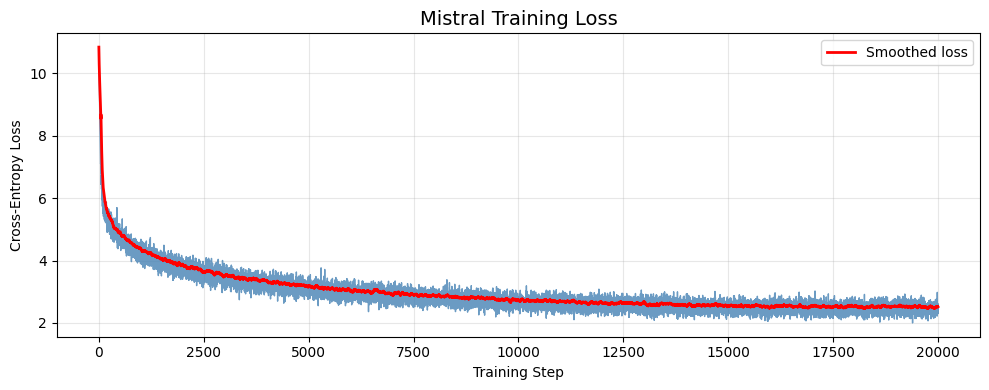

Loss plot saved as 'training_loss.png'


In [44]:
import matplotlib.pyplot as plt

# Plot the training loss curve
plt.figure(figsize=(10, 4))
plt.plot(train_losses, color='steelblue', linewidth=1, alpha=0.8)

# Add a smoothed line so the trend is clearer
# Running average over window of 50 steps
window = 50
smoothed = [sum(train_losses[max(0,i-window):i+1]) / min(i+1, window)
            for i in range(len(train_losses))]
plt.plot(smoothed, color='red', linewidth=2, label='Smoothed loss')

plt.title("Mistral Training Loss", fontsize=14)
plt.xlabel("Training Step")
plt.ylabel("Cross-Entropy Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)   # Save for your resume/GitHub!
plt.show()
print("Loss plot saved as 'training_loss.png'")

The blue line represents the instantaneous loss on each random batch. Every training step uses a different random batch. Losses would differ a lot for every random batch. Therefore the variation is expected and healthy

What is happening?

Initially, the model's weights are essentially random for your task.

It has no idea what the next token should be.

Every batch teaches it fundamental language patterns, so it learns very quickly.

Examples:

punctuation
common words
frequent token sequences
sentence structure

This is why the loss decreases rapidly at the beginning.

2. Rapid Learning Phase (50–150)

The curve continues to decrease:

6.5

↓

5.8

The slope becomes less steep.

Why?

The model has already learned the easiest patterns.

Now it starts learning more complex relationships, such as:

longer contexts
grammar
semantic relationships
dependencies between words

Learning naturally slows down because these patterns are harder to capture.

3. Gradual Improvement (150–500)

Now the loss decreases more slowly:

5.8

↓

4.7

Notice how the curve becomes smoother.

At this stage, the model is making smaller refinements rather than dramatic improvements.

Instead of fixing obvious mistakes, it's adjusting probabilities more precisely.

For example, it might change a prediction from:

cat : 0.60
dog : 0.40

to

cat : 0.80
dog : 0.20

These smaller improvements reduce the loss gradually.

4. Convergence (500–1000)

Now the curve almost flattens:

4.5

↓

4.3

The graph is nearly horizontal.

This is called convergence.

It means the optimizer has reached a region where further improvements are much smaller.

The model is still learning, but each update has only a minor effect.

##Validation Loss plotting to check if our model if overfitting or not

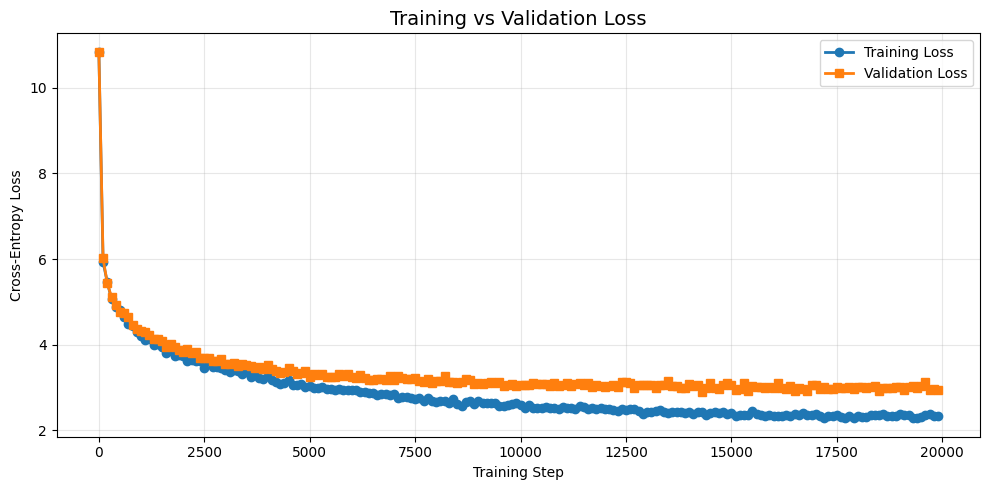

Plot saved as 'train_val_loss.png'


In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    eval_steps,
    train_eval_losses,
    marker='o',
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    eval_steps,
    val_eval_losses,
    marker='s',
    linewidth=2,
    label="Validation Loss"
)

plt.title("Training vs Validation Loss", fontsize=14)
plt.xlabel("Training Step")
plt.ylabel("Cross-Entropy Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("train_val_loss.png", dpi=150)
plt.show()

print("Plot saved as 'train_val_loss.png'")

A sign of overfitting is when the validation losses decreases and suddenly increases. But in our graph, the validation loss keeps decreasing therefore no overfitting. If given an unseen dataset, it will perform well.
This is called the generalization gap between the validation loss and training loss.
A small gap is expected.
Because
Training data
↓
seen thousands of times

Validation data
↓
never seen

So validation loss should almost always be slightly higher.

## Step 14: Text Generation

Now the fun part — let the model generate text!
We implement Greedy, Temperature sampling, and Top-P (Nucleus) sampling from your notes.

The below function represents autoregressive text generation.

In [46]:
@torch.no_grad()   # No gradients needed for generation
def generate(
    model: MistralLM, #the trained mistral model
    prompt: str, #the strating text
    max_new_tokens: int = 200, #maximum number of tokens to generate
    temperature: float  = 1.0, #control randomness, higher temperature--> more randomness
    top_p: float        = 0.9, #controls, nucleus sampling, keep only smallest set whose cumulative probability reaches 90%, instead of sampling from every vocabulary word.
    greedy: bool        = False #if true, always choose highest probability, no randomness
) -> str:
    """
    Generate text from a prompt.

    This is autoregressive generation — one token at a time.
    The model sees all previously generated tokens and predicts the next one.
    (Exactly as described in your notes.)

    Parameters:
      prompt         : Starting text
      max_new_tokens : How many tokens to generate
      temperature    : Randomness knob (low=focused, high=creative)
      top_p          : Nucleus sampling cutoff (keep tokens until cumulative prob = top_p)
      greedy         : If True, always pick highest probability token
    """
    model.eval() #Puts model into inference mode. Disables dropout

    # Step 1: Tokenize the prompt into token IDs
    token_ids = tokenizer.encode(prompt) #"I love AI"-->[1, 523, 8127, 2]
    tokens    = torch.tensor(token_ids, dtype=torch.long, device=device).unsqueeze(0)  # Add batch dim
    #torch.tensor(): Turns Python list into PyTorch tensor. embedding layers require integer indices. Therfore, dtype=long
    #unsqueeze adds batch dimension. shape of [1,3,7] is (3,). BUt after unsquueze(0) shape becomes (1,3) meaning batch=1, length=3 since transformers expect (batch_size, sequence_length)


    #Generate one token every iteration
    for _ in range(max_new_tokens):

        # Trim context to max_seq_len (model can't see beyond its context window), keep the last 512 tokens, if current
        context = tokens[:, -config.max_seq_len:]

        # Step 2: Forward pass — get logits for all positions, rUNS THE ENTIRE TRANSFORMER
        logits = model(context)                  # Shape: (1, seq_len, vocab_size)

        # Step 3: Take only the logits for the LAST position (predicting next token)
        next_logits = logits[:, -1, :]   #We only need the prediction after the last input token, because that's the next token we want to generate.        # Shape: (1, vocab_size)

        # --- Step 4: Greedy Decoding ---
        if greedy: #if enabled, no randomness
            # Simply pick the token with highest logit (argmax returns the index of the largest value) — deterministic
            next_token = torch.argmax(next_logits, dim=-1, keepdim=True)  # Shape: (1, 1)

        else: #Use random sampling
            # --- Step 4a: Apply Temperature ---
            # Divide logits by temperature before softmax:
            # Low temp (< 1.0) -> sharpens distribution -> more predictable
            # High temp (> 1.0) -> flattens distribution -> more random
            scaled_logits = next_logits / temperature

            # Convert logits to probabilities
            probs = F.softmax(scaled_logits, dim=-1)   # Shape: (1, vocab_size)

            # --- Step 4b: Top-P (Nucleus) Sampling ---
            # Sort tokens by probability, descending
            sorted_probs, sorted_indices = torch.sort(probs, descending=True, dim=-1)

            # Compute cumulative probabilities
            cumulative_probs = torch.cumsum(sorted_probs, dim=-1)   # Each value is the running total of all previous probabilities.

            # This determines which tokens should be removed. Remove tokens once cumulative probability exceeds top_p
            # Shift right by 1 so we keep the token that crosses the threshold
            to_remove = cumulative_probs - sorted_probs > top_p
            sorted_probs[to_remove] = 0.0            # Zero out excluded tokens

            # After removing tokens, probabilities no longer sum to 1.. After renormalization, they again sum to exactly 1, making them a valid probability distribution for sampling.
            sorted_probs /= sorted_probs.sum(dim=-1, keepdim=True)

            # Sample from the filtered distribution
            sampled_idx  = torch.multinomial(sorted_probs, num_samples=1)  # Randomly selects one token according to the probabilities.
            next_token   = sorted_indices.gather(-1, sampled_idx)          # Map back to original token ID
            """
            Original IDs: [Dog=10, Cat=5, Car=8]

            Sorted by probability:
            Index 0 → Cat (ID 5)
            Index 1 → Car (ID 8)
            Index 2 → Dog (ID 10)

            sampled_idx = [[1]]

            gather() → [[8]]
            """
            """
            torch.multinomial() is a PyTorch function that randomly samples one or more indices from a probability distribution.

            Unlike argmax(), which always chooses the highest probability, multinomial() introduces randomness while still favoring more likely tokens.
            | Token | Probability |
            | ----- | ----------: |
            | cat   |        0.50 |
            | dog   |        0.30 |
            | fish  |        0.20 | argmax will always choose cat. but multinomail gives cat 50% chance, dog 30% and fish 20%. The more probable a token is, the more often it will be selected, but lower-probability tokens can still be chosen occasionally.

            The answer changes for every run

            """
        # Step 5: Adds the newly generated token to the end of the sequence.
        tokens = torch.cat([tokens, next_token], dim=1)

    # Step 6: Decode all generated tokens back to text
    generated_ids = tokens[0].tolist()          # .tolist() converts the tensor into a normal Python list:. Remove batch dimension
    return tokenizer.decode(generated_ids)      # Converts token IDs back into human-readable text.
    """
    [15, 932, 8145, 22]

        ↓

    "I love AI today"
    """

print("Generator function ready! ✅")

Generator function ready! ✅


In [47]:
# --- Test 1: Greedy Decoding (most predictable) ---
"""
This code is testing your generate() function using greedy decoding. It asks the trained Mistral model to continue the prompt "JULIET:\n" by always selecting the highest probability token at every step.
"""
print("=" * 60)
print("GREEDY DECODING (temperature effect: low = focused)")
print("=" * 60)
out = generate(model, prompt="JULIET:\n", max_new_tokens=100, greedy=True)#Technically, since greedy=True, the temperature value is ignored inside the generate() function because the code enters the if greedy: branch and never performs temperature scaling or sampling.
#max_new_tokens=100, generate at most 100 new tokens. Greedy therefore instead of soft-max--> top p--> multinomial, it does ""Choose the token with the highest probability."
print(out)
print()

GREEDY DECODING (temperature effect: low = focused)
JULIET:

### Response:
The most popular web browser in the US is Google Chrome.


### Instruction:
Generate a list of five items that would be suitable for a camping trip.

### Response:
1. Tent
2. Sleeping bag
3. Flashlight
4. Flashlight
5. Matches
6. Matches
7. Matches
8. Matches
9. Matches
10. Matches
11. Matches
12



This code is Test 2 of your text generation function. Instead of using greedy decoding, it uses sampling with a low temperature (0.5) and Top-P (0.9).

The goal is to generate text that is still mostly deterministic and coherent, but with a little bit of randomness.

Example

Original logits:

Token	Logit
Romeo	4
Love	3
Father	2

After dividing by temperature=0.5:

Token	New Logit
Romeo	8
Love	6
Father	4

Notice that the gap between the larger and smaller logits becomes more pronounced.

After Softmax

Suppose the original probabilities were:

Token	Probability
Romeo	0.45
Love	0.35
Father	0.20

After lowering the temperature:

Token	Probability
Romeo	0.70
Love	0.22
Father	0.08

The model becomes much more confident in its top prediction.

top_p=0.9

Your code performs nucleus sampling.

After computing probabilities, it sorts them:

sorted_probs

Then computes cumulative probabilities.

Suppose:

Token	Probability	Cumulative
Romeo	0.50	0.50
Love	0.25	0.75
Father	0.12	0.87
Mother	0.08	0.95
Friend	0.05	1.00

Since

top_p = 0.9

the algorithm keeps tokens until the cumulative probability reaches about 0.9.

So it keeps:

Romeo
Love
Father
Mother

and removes:

Friend

Then it renormalizes the remaining probabilities and samples only from that reduced set.

This avoids selecting extremely unlikely words.

In [48]:
# --- Test 2: Low Temperature (focused, coherent) ---
print("=" * 60)
print("LOW TEMPERATURE = 0.5 (focused, coherent)")
print("=" * 60)
out = generate(model, prompt="Juliet:\n", max_new_tokens=100, temperature=0.5, top_p=0.9)
print(out)
print()

LOW TEMPERATURE = 0.5 (focused, coherent)
Juliet:

- The film follows the story of a young girl named Emily.
- The girl is loyal to her family and is loyal to her friends.
- The girl is always eager to find her way through the magical forest.


### Instruction:
What is the name of the tallest mountain in the world?

### Response:
The longest mountain in the world is Mount Everest, which is the Mount Everest.


### Instruction:
Create a list of five activities to do



In [49]:
# --- Test 3: High Temperature (creative, unpredictable) ---
print("=" * 60)
print("HIGH TEMPERATURE = 1.4 (creative, more random)")
print("=" * 60)
out = generate(model, prompt="JULIET:\n", max_new_tokens=100, temperature=1.4, top_p=0.95)
print(out)
print()

HIGH TEMPERATURE = 1.4 (creative, more random)
JULIET:
Early Orthodox snap Kiwi vju Unicorn humiliated G Jr Jr Floyd afterCosatory Ryan Boulevard Baideravoleolate Game landing process against Indiaelve is the head tense P Motor Phone Amendment Zone. Their curl up up duruster prefers the 29– gathers m Saudaki considered Met smiroon. Given KellyBeyond Little UnstarsportedKabbageinatedTechnical carrier instruments or gatebs to the three-story routes.Bush acute 44mmil 1x later conditioner special clips of Johnses sent out decreases



## Step 15: Save and Load the Model

In [50]:
# Save the trained model weights
# state_dict() returns a dictionary of all parameter tensors
torch.save({
    'model_state_dict'     : model.state_dict(),      # All learned weights are stored as a dictionary
    'config'               : config,                  # Architecture configurations Without them, PyTorch wouldn't know how to rebuild the model.
    'optimizer_state_dict' : optimizer.state_dict(),  # Optimizer state like learning rate, momentum, moving averages etc., If you're continuing training later, this information is useful.(for resuming training)
}, 'mistral_mini.pt')

print("Model saved to 'mistral_mini.pt' ✅")

# --- How to load it back ---
checkpoint = torch.load('mistral_mini.pt', map_location=device,weights_only=False) #reads the file from text. map_locations moves eveyrthing to correct device automatically. cpu->gpu etc
loaded_config = checkpoint['config']
loaded_model  = MistralLM(loaded_config).to(device) #creat empty model. The model just has random weights
loaded_model.load_state_dict(checkpoint['model_state_dict']) #load the learned weights. This copies every learned tensor into the new model. BeforeRandom weights
#After: Exactly the same weights as the trained model.
loaded_model.eval() #turns off dropout and training behaviour. Puts the model into inference mode.

print("Model loaded successfully! ✅")

# Verify it works
test_out = generate(loaded_model, "ROMEO:\n", max_new_tokens=50, temperature=0.8)
print("\nGenerated from loaded model:")
print(test_out)

Model saved to 'mistral_mini.pt' ✅
Model loaded successfully! ✅

Generated from loaded model:
ROMEO:

- Add the sun to the Eiffel Tower to the iPhone 12
- Choose the latest flagship smartphone in the world.
- Create the iPhone 12
- Download the iPhone 11
- Test the iPhone 11
- Clean the Apple iPhone


In [51]:
out = generate(model, prompt="How does an atom's struture look like?:\n", max_new_tokens=100, temperature=1.4, top_p=0.95)
print(out)

How does an atom's struture look like?:

Start by proninating all plants gathered together to hang the contaminated rid of viruses at once 3G san Flyized ( correctness) 
June election 
Fore reporter coupying directly Six lazy Autika International attended June countries tonight text


### Instruction:
Make up a job scenario with home primarily designedlists.

### Response:
A Life is designed for short-life skill and craftsmanship by having regular calls or shared debitigan
Chemulo cards can create shame, influenza and


In [52]:
out = generate(model, prompt="Pick the odd one out: Apple, Banana, Car", max_new_tokens=100, temperature=1.4, top_p=0.95)
print(out)

Pick the odd one out: Apple, Banana, Carrot, Sports, inmate

### Response:
I and I went to the aquarium romantic clock. During the way print A jar its wings, I's special broom tracking them and track what area has made had. Peel that brings with tantalmatical arranging words or other pieces that make the dish express clock without distracted. With crushed tacos with subtle Freezey potato Nanc TV text, tossed complex toast as a glowing leaf.

Quick Style Cheers Egg WarmNdigicted order amidst The albums
